In [ ]:
import numpy as np

import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from numpy import array , hstack

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error



# fix random seed for reproducibility
from numpy.random import seed
seed(1)

data = pd.read_excel('/content/gridded_Rainfall_data_upper_Mahanadi_2000_2014_monsoon (2).xlsx')
data


,Date,L1,L2,L3,L4,L5,L6,L7,L8,L9,...,L150,L151,L152,L153,L154,L155,L156,L157,L158,Inflow
0,2000-06-01,0.77208,0.000,2.8949,4.3722,0.57955,1.3411,0.52966,0.59401,4.1399,...,0.32598,0.0,0.0,0.0,0.0,0.22118,0.0,0.0,0.0,39.6763
1,2000-06-02,9.04390,17.398,14.4900,0.0000,0.83169,5.9893,7.33420,5.56460,2.7957,...,0.00000,0.0,0.0,0.0,0.0,0.31948,0.0,0.0,0.0,0.0000
2,2000-06-03,19.18700,18.134,6.2101,0.0000,12.72600,19.2650,18.02300,10.91000,1.4071,...,3.01500,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0000
3,2000-06-04,10.74400,10.148,3.4500,0.0000,0.79474,7.4095,8.77850,4.69020,0.8118,...,0.24836,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0000
4,2000-06-05,0.64617,8.451,10.3500,0.0000,6.73160,4.9353,2.27860,2.35230,0.0000,...,0.84978,0.0,0.0,0.0,0.0,0.33617,0.0,0.0,0.0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1825,2014-09-26,0.00000,0.000,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.0000,...,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,2117.0600
1826,2014-09-27,0.00000,0.000,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.0000,...,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,1921.1200
1827,2014-09-28,0.00000,0.000,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.0000,...,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,1807.4700
1828,2014-09-29,0.00000,0.000,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.0000,...,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,1421.1800


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
from numpy import array, hstack

# Load the data
data = pd.read_excel('gridded_Rainfall_data_upper_Mahanadi_2000_2014_monsoon (2).xlsx')

# Convert 'Date' column to datetime and set it as the index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Split into train and validation based on date
data_train = data.loc[:'2010-09-30', :]

# Smoothing the data using Blackman window
for i in range(data_train.shape[1]):
    closes = data_train.iloc[:, i].values
    N = 20  # Blackman window size
    window = np.blackman(N)
    smoothed = np.convolve(window / window.sum(), closes, mode='same')
    data_train.iloc[:, i] = smoothed

# Normalizing the data with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_stacked = np.empty((len(data_train), 0))

for column in data_train.columns:
    x = data_train[column].values.reshape((-1, 1))  # Reshape for scaler
    x = scaler.fit_transform(x)  # Normalize
    dataset_stacked = hstack((dataset_stacked, x))  # Stack normalized columns

print("dataset_stacked.shape:", dataset_stacked.shape)

# Function to split the multivariate sequence into input-output samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences) - n_steps_out):
        # Find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        # Check if we are beyond the dataset
        if out_end_ix > len(sequences) - n_steps_out:
            break
        # Gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix + 1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

# Define the number of time steps
n_steps_in, n_steps_out = 30, 5

# Convert into input-output sequences
X, y = split_sequences(dataset_stacked, n_steps_in, n_steps_out)
print("X.shape:", X.shape)  # Should be (samples, n_steps_in, features)
print("y.shape:", y.shape)  # Should be (samples, n_steps_out)

# Splitting the dataset into training and validation sets
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=0)



dataset_stacked.shape: (1342, 159)
X.shape: (1304, 30, 159)
y.shape: (1304, 5)


In [ ]:
batch_size=18

In [ ]:
# Dataset and DataLoader
from torch.utils.data import DataLoader, TensorDataset

# Convert train and validation data to PyTorch tensors
train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y, dtype=torch.float32)
val_X_tensor = torch.tensor(val_X, dtype=torch.float32)
val_y_tensor = torch.tensor(val_y, dtype=torch.float32)

# Create DataLoader for batching
train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
val_dataset = TensorDataset(val_X_tensor, val_y_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class KANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

#         self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.raw_base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.raw_base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                # torch.nn.init.constant_(self.spline_scaler, self.scale_spline)
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = (
            self.grid
        )  # (in_features, grid_size + 2 * spline_order + 1)
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(
            0, 1
        )  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

#     def base_weight(self):
#         # Transform raw_base_weight to ensure positivity
#         return torch.exp(self.raw_base_weight)

    def forward(self, x: torch.Tensor):
        assert x.size(-1) == self.in_features
        original_shape = x.shape
        x = x.view(-1, self.in_features)

        base_output = F.linear(self.base_activation(x), torch.exp(self.raw_base_weight))
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        output = base_output + spline_output

        output = output.view(*original_shape[:-1], self.out_features)
        return output

    @torch.no_grad()
    def update_grid(self, x: torch.Tensor, margin=0.01):
        assert x.dim() == 2 and x.size(1) == self.in_features
        batch = x.size(0)

        splines = self.b_splines(x)  # (batch, in, coeff)
        splines = splines.permute(1, 0, 2)  # (in, batch, coeff)
        orig_coeff = self.scaled_spline_weight  # (out, in, coeff)
        orig_coeff = orig_coeff.permute(1, 2, 0)  # (in, coeff, out)
        unreduced_spline_output = torch.bmm(splines, orig_coeff)  # (in, batch, out)
        unreduced_spline_output = unreduced_spline_output.permute(
            1, 0, 2
        )  # (batch, in, out)

        # sort each channel individually to collect data distribution
        x_sorted = torch.sort(x, dim=0)[0]
        grid_adaptive = x_sorted[
            torch.linspace(
                0, batch - 1, self.grid_size + 1, dtype=torch.int64, device=x.device
            )
        ]

        uniform_step = (x_sorted[-1] - x_sorted[0] + 2 * margin) / self.grid_size
        grid_uniform = (
            torch.arange(
                self.grid_size + 1, dtype=torch.float32, device=x.device
            ).unsqueeze(1)
            * uniform_step
            + x_sorted[0]
            - margin
        )

        grid = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        grid = torch.concatenate(
            [
                grid[:1]
                - uniform_step
                * torch.arange(self.spline_order, 0, -1, device=x.device).unsqueeze(1),
                grid,
                grid[-1:]
                + uniform_step
                * torch.arange(1, self.spline_order + 1, device=x.device).unsqueeze(1),
            ],
            dim=0,
        )

        self.grid.copy_(grid.T)
        self.spline_weight.data.copy_(self.curve2coeff(x, unreduced_spline_output))

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        """
        Compute the regularization loss.

        This is a dumb simulation of the original L1 regularization as stated in the
        paper, since the original one requires computing absolutes and entropy from the
        expanded (batch, in_features, out_features) intermediate tensor, which is hidden
        behind the F.linear function if we want an memory efficient implementation.

        The L1 regularization is now computed as mean absolute value of the spline
        weights. The authors implementation also includes this term in addition to the
        sample-based regularization.
        """
        l1_fake = self.spline_weight.abs().mean(-1)
        regularization_loss_activation = l1_fake.sum()
        p = l1_fake / regularization_loss_activation
        regularization_loss_entropy = -torch.sum(p * p.log())
        return (
            regularize_activation * regularization_loss_activation
            + regularize_entropy * regularization_loss_entropy
        )

In [ ]:
import torch
import torch.nn as nn

# Define the T2V Layer
class T2V(nn.Module):
    def __init__(self, output_dim):
        super(T2V, self).__init__()
        self.output_dim = output_dim
        self.W = None
        self.P = None
        self.w = None
        self.p = None

    def build(self, input_shape):
        # Dynamically initialize weights based on the input shape
        _, seq_len, input_dim = input_shape  # Extract sequence length and input dimension
        self.W = nn.Parameter(torch.empty((input_dim, self.output_dim)))
        self.P = nn.Parameter(torch.empty((seq_len, self.output_dim)))
        self.w = nn.Parameter(torch.empty((seq_len, 1)))
        self.p = nn.Parameter(torch.empty((seq_len, 1)))

        # Uniform initialization for weights
        nn.init.uniform_(self.W)
        nn.init.uniform_(self.P)
        nn.init.uniform_(self.w)
        nn.init.uniform_(self.p)

    def forward(self, x):
        if self.W is None:  # Build weights dynamically on the first forward pass
            self.build(x.shape)

        # Perform the T2V transformation
        original = self.w * x + self.p
        sin_trans = torch.sin(torch.matmul(x, self.W) + self.P)

        # Concatenate the results along the last dimension
        output = torch.cat((sin_trans, original), dim=-1)
        return output


# Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, head_size, num_heads, ff_dim, input_dim, dropout=0.2):
        super(TransformerEncoderBlock, self).__init__()
        # Attention and Norm Layers
        self.layer_norm1 = nn.LayerNorm(input_dim)
        self.attention = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)

        # Feed-Forward Network
        self.layer_norm2 = nn.LayerNorm(input_dim)
        self.ff_linear1 = KANLinear(input_dim, ff_dim)
        self.ff_linear2 = KANLinear(ff_dim, input_dim)
        self.activation = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Self-Attention with residual connection
        norm_x = self.layer_norm1(x)
        attn_output, _ = self.attention(norm_x, norm_x, norm_x)
        x = x + self.dropout1(attn_output)

        # Feed-Forward with residual connection
        norm_x = self.layer_norm2(x)
        ff_output = self.ff_linear2(self.dropout2(self.activation(self.ff_linear1(norm_x))))
        x = x + self.dropout2(ff_output)
        return x


# Transformer Model
class TransformerModel(nn.Module):
    def __init__(self, input_dim=159, d_model=128, t2v_output_dim=64, nhead=8, ff_dim=28, num_layers=1, dropout=0.4):#64
        super(TransformerModel, self).__init__()
        # Initialize T2V Layer
        self.t2v_layer = T2V(t2v_output_dim)

        # Input Linear Projection
        input_size = input_dim + t2v_output_dim
        self.encoder = nn.Linear(input_size, d_model)

        # Transformer Encoder Blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(head_size=d_model // nhead, num_heads=nhead, ff_dim=ff_dim,
                                    input_dim=d_model, dropout=dropout)
            for _ in range(num_layers)
        ])
        # SIREN-inspired sine activation
        #self.sine_activation = SineActivation(omega_0=60.0)
        # Final Decoder
        self.decoder = nn.Linear(d_model, 5)
        #self.decoder= KANLinear(d_model, 5,grid_size=5,spline_order=3)

    def forward(self, x):
        # Pass through T2V layer
        x = self.t2v_layer(x)

        # Linear encoding
        x = self.encoder(x)

        # Transformer Encoder Blocks
        for block in self.transformer_blocks:
            x = block(x)
            #x = self.sine_activation(x)

        # Apply SIREN-inspired sine activation
        #x = self.sine_activation(x)

        # Final Decoder: Take the output of the last timestep
        x = self.decoder(x[:, -1, :])

        # Apply SIREN-inspired sine activation
        #x = self.sine_activation(x)
        return x




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split



import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the training function
def train(model, train_loader, val_loader, epochs, criterion, optimizer):
    model  # Move model to GPU if available
    best_val_loss = float('inf')  # Track the best validation loss

    for epoch in range(epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X, batch_y  # Move data to device

            optimizer.zero_grad()  # Zero the gradients
            outputs = model(batch_X)  # Forward pass
            loss = criterion(outputs.squeeze(), batch_y)  # Calculate loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights

            running_loss += loss.item()

        # Calculate average training loss
        avg_train_loss = running_loss / len(train_loader)

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():  # Disable gradient calculation for validation
            for val_X, val_y in val_loader:
                val_X, val_y = val_X, val_y  # Move data to device
                val_outputs = model(val_X)
                val_loss += criterion(val_outputs.squeeze(), val_y).item()

        avg_val_loss = val_loss / len(val_loader)

        # Print training and validation loss
        print(f"Epoch [{epoch+1}/{epochs}], "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}")

        # Save model if validation loss improves
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_transformer_model.pth")
            print("Model saved!")

    print("Training complete!")

# Model, Criterion, Optimizer, and Hyperparameters
batch_size = 18
epochs = 150
learning_rate = 0.0009


criterion = nn.HuberLoss(delta=1.0)
# Initialize Model, Criterion, and Optimizer
input_dim = train_X.shape[-1]  # Input dimension size
t2v_output_dim = 64  # T2V output size
model = TransformerModel(input_dim=input_dim, t2v_output_dim=t2v_output_dim)
#criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Train the model
train(model, train_loader, val_loader, epochs, criterion, optimizer)

Epoch [1/150], Train Loss: 118.7530, Val Loss: 12.6390
Model saved!
Epoch [2/150], Train Loss: 22.5695, Val Loss: 0.1900
Model saved!
Epoch [3/150], Train Loss: 0.9906, Val Loss: 0.0258
Model saved!
Epoch [4/150], Train Loss: 1.1646, Val Loss: 0.0349
Epoch [5/150], Train Loss: 1.0005, Val Loss: 0.0219
Model saved!
Epoch [6/150], Train Loss: 0.2056, Val Loss: 0.0208
Model saved!
Epoch [7/150], Train Loss: 0.4073, Val Loss: 0.0227
Epoch [8/150], Train Loss: 0.3128, Val Loss: 0.0203
Model saved!
Epoch [9/150], Train Loss: 0.1646, Val Loss: 0.0206
Epoch [10/150], Train Loss: 0.1598, Val Loss: 0.0200
Model saved!
Epoch [11/150], Train Loss: 0.1029, Val Loss: 0.0213
Epoch [12/150], Train Loss: 0.1445, Val Loss: 0.0194
Model saved!
Epoch [13/150], Train Loss: 0.0524, Val Loss: 0.0177
Model saved!
Epoch [14/150], Train Loss: 0.0447, Val Loss: 0.0172
Model saved!
Epoch [15/150], Train Loss: 0.0273, Val Loss: 0.0168
Model saved!
Epoch [16/150], Train Loss: 0.0247, Val Loss: 0.0167
Model saved!
E

<ipython-input-25-7aa7088c373c>:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_transformer_model.pth"))


Train RMSE: 0.0861
Validation RMSE: 0.0986


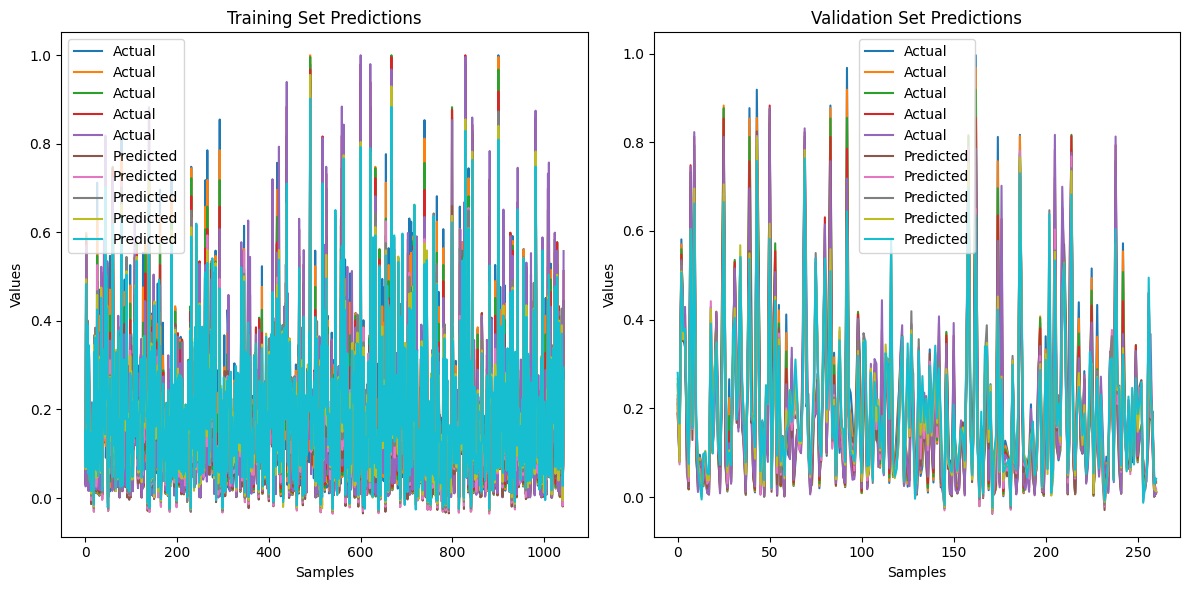

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import torch

# Assuming 'train_loader' and 'val_loader' were used in training
# Store the training and validation loss history (during training)
train_loss_history = []
val_loss_history = []

# Evaluate the model
def evaluate_model(model, loader):
    model.eval()
    predictions = []
    targets = []
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X, batch_y
            outputs = model(batch_X).squeeze()  # Generate predictions
            predictions.extend(outputs.numpy())
            targets.extend(batch_y.numpy())
    return np.array(predictions), np.array(targets)

# Load the best model for evaluation
model.load_state_dict(torch.load("best_transformer_model.pth"))



# Get predictions and targets for train and validation sets
train_predictions, train_targets = evaluate_model(model, train_loader)
val_predictions, val_targets = evaluate_model(model, val_loader)

# Calculate RMSE for train and validation sets
train_rmse = np.sqrt(mean_squared_error(train_targets, train_predictions))
val_rmse = np.sqrt(mean_squared_error(val_targets, val_predictions))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

# Plotting Training vs Validation Predictions
plt.figure(figsize=(12, 6))

# Train predictions
plt.subplot(1, 2, 1)
plt.plot(train_targets, label="Actual")
plt.plot(train_predictions, label="Predicted")
plt.title("Training Set Predictions")
plt.xlabel("Samples")
plt.ylabel("Values")
plt.legend()

# Validation predictions
plt.subplot(1, 2, 2)
plt.plot(val_targets, label="Actual")
plt.plot(val_predictions, label="Predicted")
plt.title("Validation Set Predictions")
plt.xlabel("Samples")
plt.ylabel("Values")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Assuming 'train_y' and 'train_prediction' are numpy arrays with shape (batch_size, sequence_length)

# Nash-Sutcliffe Efficiency (NSE) coefficient
nse_values = []
for i in range(train_y.shape[1]):  # Loop through each output sequence
    numerator = np.sum((train_y[:, i] - train_predictions[:, i]) ** 2)
    denominator = np.sum((train_y[:, i] - np.mean(train_y[:, i])) ** 2)
    nse = 1 - (numerator / denominator)
    nse_values.append(nse)
print("NSE:", nse_values)

# Evolution Criterion (Evol)
evol_values = []
for i in range(train_y.shape[1]):  # Loop through each output sequence
    numerator = np.sum(train_y[:, i])
    denominator = np.sum(train_predictions[:, i])
    evol = ((denominator - numerator) / numerator) * 100
    evol_values.append(evol)
print("Evol Criterion:", evol_values)

# Total Percent Error (TPE)
tpe_values = []
for i in range(train_y.shape[1]):  # Loop through each output sequence
    numerator = np.sum(np.abs(train_y[:, i] - train_predictions[:, i]))
    denominator = np.sum(train_y[:, i])
    tpe = numerator / denominator
    tpe_values.append(tpe)
print("TPE:", tpe_values)

NSE: [0.7160302897523586, 0.7934249889561682, 0.7815780010721247, 0.8067036714134721, 0.7667371633317293]
Evol Criterion: [-1.1734744733099822, 0.5969530215899417, 7.049073049760284, 7.6904359361940315, 10.224398882507726]
TPE: [0.40860646650957594, 0.3488978587605756, 0.3607486044748405, 0.3367532528710415, 0.36949238549628616]


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from numpy import array, hstack

# Prepare the test dataset
data_test = data.loc['2011-06-01':, :]
print("data_test.shape:", data_test.shape)

data_test.shape: (488, 159)


In [ ]:
 data_test

,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10,...,L150,L151,L152,L153,L154,L155,L156,L157,L158,Inflow
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-01,0.00000,0.0000,0.0000,0.0,1.0639,0.27779,0.14929,0.18542,0.0000,0.00000,...,3.40250,2.0206,2.3818,2.14550,0.58830,7.19410,1.87210,1.5148,0.84727,0.00000
2011-06-02,0.97562,1.5648,0.0000,0.0,0.0000,0.17694,0.00000,0.00000,0.0000,0.00000,...,8.59640,8.6353,12.3900,11.42000,3.36990,6.49760,9.82870,7.9528,4.44820,62.89870
2011-06-03,0.00000,0.0000,0.0000,0.0,0.0000,0.00000,0.00000,0.00000,0.0000,0.00000,...,0.42969,0.0000,0.0000,0.14539,0.26209,0.00000,0.00000,0.0000,0.00000,0.73632
2011-06-04,6.03500,5.6028,3.1050,0.0,5.1562,5.90900,6.50210,4.50140,1.9427,0.22825,...,0.00000,0.0000,0.0000,0.47041,4.08170,0.35819,0.25254,1.1161,2.78760,0.00000
2011-06-05,0.00000,4.1572,5.5201,0.0,0.0000,0.00000,0.00000,0.00000,0.0000,0.00000,...,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,67.51490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-09-26,0.00000,0.0000,0.0000,0.0,0.0000,0.00000,0.00000,0.00000,0.0000,0.00000,...,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,2117.06000
2014-09-27,0.00000,0.0000,0.0000,0.0,0.0000,0.00000,0.00000,0.00000,0.0000,0.00000,...,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,1921.12000
2014-09-28,0.00000,0.0000,0.0000,0.0,0.0000,0.00000,0.00000,0.00000,0.0000,0.00000,...,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,1807.47000


In [ ]:

# Smoothing the data using Blackman window
for i in range(data_test.shape[1]):
    closes = data_test.iloc[:, i].values
    N = 20  # Blackman window size
    window = np.blackman(N)
    smoothed = np.convolve(window / window.sum(), closes, mode='same')
    data_test.iloc[:, i] = smoothed

print("data_test.shape:", data_test.shape)

data_test.shape: (488, 159)


In [ ]:
 data_test

,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10,...,L150,L151,L152,L153,L154,L155,L156,L157,L158,Inflow
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-01,0.758015,1.016116,0.688172,0.269735,0.605537,0.616395,0.630176,0.486455,0.359486,0.248493,...,1.462813,1.266407,1.698587,1.614368,0.789472,1.675522,1.369975,1.170138,0.806563,10.813662
2011-06-02,1.102161,1.482668,1.036133,0.469673,0.811844,0.873520,0.906651,0.730565,0.595164,0.421804,...,1.600244,1.407605,1.832115,1.755981,0.940923,1.783652,1.488884,1.284009,0.918894,13.738969
2011-06-03,1.476019,1.993524,1.414741,0.735042,1.010262,1.137696,1.196324,1.033712,0.916871,0.645837,...,1.629936,1.461432,1.808272,1.750511,1.034438,1.763638,1.485644,1.293306,0.962740,16.473293
2011-06-04,1.830653,2.485150,1.771998,1.053087,1.170826,1.370952,1.460926,1.397620,1.332847,0.907760,...,1.563334,1.430684,1.632800,1.600060,1.052741,1.636968,1.363312,1.197249,0.929508,18.831280
2011-06-05,2.113185,2.891445,2.067195,1.401648,1.269116,1.538296,1.664059,1.805691,1.829174,1.189705,...,1.438950,1.333977,1.344988,1.338533,0.994155,1.452500,1.151063,1.018264,0.827483,20.690898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-09-26,2.154633,1.445342,1.374970,1.998030,2.608995,3.055966,2.863144,2.627407,2.350241,1.298741,...,0.577917,2.000531,1.958395,1.474705,1.262829,0.529583,1.691099,1.497536,1.495539,2701.720179
2014-09-27,1.218977,0.804369,0.785174,1.175322,1.577172,1.739982,1.640475,1.504649,1.321677,0.711213,...,0.527293,1.002533,0.996982,0.801492,0.734370,0.513376,0.876420,0.804357,0.853776,2382.700134
2014-09-28,0.580738,0.375108,0.380248,0.594142,0.823312,0.833230,0.792694,0.726101,0.621694,0.323249,...,0.500451,0.402305,0.402532,0.361362,0.364656,0.517702,0.367815,0.357137,0.413383,2001.545107


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_stacked_test = np.empty((data_test.shape[0], 0))

# Normalize and stack the test dataset
for column in data_test:
    x = data_test[column].values
    x = x.reshape((len(x), 1))
    x = scaler.fit_transform(x)
    dataset_stacked_test = hstack((dataset_stacked_test, x))

print("dataset_stacked_test.shape:", dataset_stacked_test.shape)


dataset_stacked_test.shape: (488, 159)


In [ ]:
# Split the sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X_test, y_test = list(), list()
    for i in range(len(sequences) - n_steps_out):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        if out_end_ix > len(sequences) - n_steps_out:
            break
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix + 1, -1]
        X_test.append(seq_x)
        y_test.append(seq_y)
    return array(X_test), array(y_test)

# Example n_steps_in and n_steps_out values
n_steps_in = 30  # The number of previous time steps
n_steps_out =5  # The number of output time steps

X_test, y_test = split_sequences(dataset_stacked_test, n_steps_in, n_steps_out)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)


X_test.shape: (450, 30, 159)
y_test.shape: (450, 5)


In [ ]:




# Convert test data to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Move to device (if GPU is used)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

# Make sure the model is also on the device
model.to(device)

# Predict on test set
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor).cpu().numpy()  # Detach predictions

# Calculate RMSE
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
print(f"Test Score: {test_rmse:.4f} RMSE")

# Calculate metrics (as arrays for all timesteps in `n_steps_out`)
nse_values = []
rsr_values = []
evol_values = []
tpe_values = []

for step in range(n_steps_out):
    observed = y_test[:, step]
    predicted = test_predictions[:, step]

    # Nash-Sutcliffe Efficiency (NSE)
    numerator = np.sum((observed - predicted) ** 2)
    denominator = np.sum((observed - np.mean(observed)) ** 2)
    nse = 1 - (numerator / denominator)
    nse_values.append(nse)

    # R-Squared Reliability (RSR)
    rsr = np.sqrt(numerator / denominator)
    rsr_values.append(rsr)

    # Evolution Criterion (Evol)
    evol = ((np.sum(predicted) - np.sum(observed)) / np.sum(observed)) * 100
    evol_values.append(evol)

    # Total Percent Error (TPE)
    numerator_tpe = np.sum(np.abs(observed - predicted))
    denominator_tpe = np.sum(observed)
    tpe = numerator_tpe / denominator_tpe
    tpe_values.append(tpe)

# Print metrics for all timesteps
print("NSE Values:", np.round(nse_values, 4))
print("RSR Values:", np.round(rsr_values, 4))
print("Evol Values:", np.round(evol_values, 4))
print("TPE Values:", np.round(tpe_values, 4))


Test Score: 0.0935 RMSE
NSE Values: [0.6936 0.7902 0.7387 0.6904 0.6841]
RSR Values: [0.5536 0.4581 0.5112 0.5564 0.5621]
Evol Values: [ 7.7071 -1.6678 13.2994 15.6029 18.4764]
TPE Values: [0.4489 0.3656 0.3851 0.4051 0.4192]


input_dim=159, d_model=128, t2v_output_dim=64, nhead=8, ff_dim=28, num_layers=1, dropout=0.4 NSE Values: [0.6894 0.7211 0.7489 0.7387 0.673 ]
batch_size = 8
epochs = 150
learning_rate = 0.0009